In [2]:
import numpy as np
import math as m
from numpy import linalg as LA
import matplotlib.pyplot as plt
%matplotlib notebook

In [3]:
#params from pmt datasheet
fov=np.deg2rad(45) #angle of view
inner_radius=21.5 #cm, need more precise geometry!
pmt_length= 13.8#cm
distance_pmt_end_to_center=inner_radius-pmt_length

#generate a "cross"
v1=([distance_pmt_end_to_center,0,0])
v2=([0,0,-distance_pmt_end_to_center])
v3=([-distance_pmt_end_to_center,0,0])
v4=([0,0,distance_pmt_end_to_center])


#rotation matrix:  
def Rx(theta):
    theta=np.deg2rad(theta)
    return np.matrix([[ 1, 0           , 0           ],
                   [ 0, m.cos(theta),-m.sin(theta)],
                   [ 0, m.sin(theta), m.cos(theta)]])
  
def Ry(theta):
    theta=np.deg2rad(theta)
    return np.matrix([[ m.cos(theta), 0, m.sin(theta)],
                   [ 0           , 1, 0           ],
                   [-m.sin(theta), 0, m.cos(theta)]])
  
def Rz(theta):
    theta=np.deg2rad(theta)
    return np.matrix([[ m.cos(theta), -m.sin(theta), 0 ],
                   [ m.sin(theta), m.cos(theta) , 0 ],
                   [ 0           , 0            , 1 ]])

In [4]:
Rz(57.5).dot(v1),Rx(57.5).dot(v2),Rz(-57.5).dot(v3),Rx(-57.5).dot(v4)

(matrix([[4.13720698, 6.49411413, 0.        ]]),
 matrix([[ 0.        ,  6.49411413, -4.13720698]]),
 matrix([[-4.13720698,  6.49411413,  0.        ]]),
 matrix([[0.        , 6.49411413, 4.13720698]]))

In [5]:
(Ry(45)*Rz(25)).dot(v1),(Ry(45)*Rx(25)).dot(v2),(Ry(45)*Rz(-25)).dot(v3),(Ry(45)*Rx(-25)).dot(v4)

(matrix([[ 4.93459414,  3.25416062, -4.93459414]]),
 matrix([[-4.93459414,  3.25416062, -4.93459414]]),
 matrix([[-4.93459414,  3.25416062,  4.93459414]]),
 matrix([[4.93459414, 3.25416062, 4.93459414]]))

In [6]:
#rotate 57.5
vec1=np.asarray(Rz(57.5).dot(v1))
vec2=np.asarray(Rx(57.5).dot(v2))
vec3=np.asarray(Rz(-57.5).dot(v3))
vec4=np.asarray(Rx(-57.5).dot(v4))
#rotate 25 then 45
vec5=np.asarray((Ry(45)*Rz(25)).dot(v1))
vec6=np.asarray((Ry(45)*Rx(25)).dot(v2))
vec7=np.asarray((Ry(45)*Rz(-25)).dot(v3))
vec8=np.asarray((Ry(45)*Rx(-25)).dot(v4))

vec1,vec2,vec3,vec4,vec5,vec6,vec7,vec8

(array([[4.13720698, 6.49411413, 0.        ]]),
 array([[ 0.        ,  6.49411413, -4.13720698]]),
 array([[-4.13720698,  6.49411413,  0.        ]]),
 array([[0.        , 6.49411413, 4.13720698]]),
 array([[ 4.93459414,  3.25416062, -4.93459414]]),
 array([[-4.93459414,  3.25416062, -4.93459414]]),
 array([[-4.93459414,  3.25416062,  4.93459414]]),
 array([[4.93459414, 3.25416062, 4.93459414]]))

In [7]:
#the other half, flip over x-z plane
vec9=np.array([[4.13720698, -6.49411413, 0.        ]])
vec10=np.array([[ 0.        ,  -6.49411413, -4.13720698]])
vec11=np.array([[-4.13720698,  -6.49411413,  0.        ]])
vec12=np.array([[0.        , -6.49411413, 4.13720698]])

vec13=np.array([[ 4.93459414,  -3.25416062, -4.93459414]])
vec14=np.array([[-4.93459414,  -3.25416062, -4.93459414]])
vec15=np.array([[-4.93459414,  -3.25416062,  4.93459414]])
vec16=np.array([[4.93459414, -3.25416062, 4.93459414]])

In [8]:
x=np.array([vec1[0][0],vec2[0][0],vec3[0][0],vec4[0][0],vec5[0][0],vec6[0][0],vec7[0][0],vec8[0][0],vec9[0][0],vec10[0][0],vec11[0][0],vec12[0][0],vec13[0][0],vec14[0][0],vec15[0][0],vec16[0][0]])
y=np.array([vec1[0][1],vec2[0][1],vec3[0][1],vec4[0][1],vec5[0][1],vec6[0][1],vec7[0][1],vec8[0][1],vec9[0][1],vec10[0][1],vec11[0][1],vec12[0][1],vec13[0][1],vec14[0][1],vec15[0][1],vec16[0][1]])
z=np.array([vec1[0][2],vec2[0][2],vec3[0][2],vec4[0][2],vec5[0][2],vec6[0][2],vec7[0][2],vec8[0][2],vec9[0][2],vec10[0][2],vec11[0][2],vec12[0][2],vec13[0][2],vec14[0][2],vec15[0][2],vec16[0][2]])

In [11]:
z

array([ 0.        , -4.13720698,  0.        ,  4.13720698, -4.93459414,
       -4.93459414,  4.93459414,  4.93459414,  0.        , -4.13720698,
        0.        ,  4.13720698, -4.93459414, -4.93459414,  4.93459414,
        4.93459414])

<IPython.core.display.Javascript object>


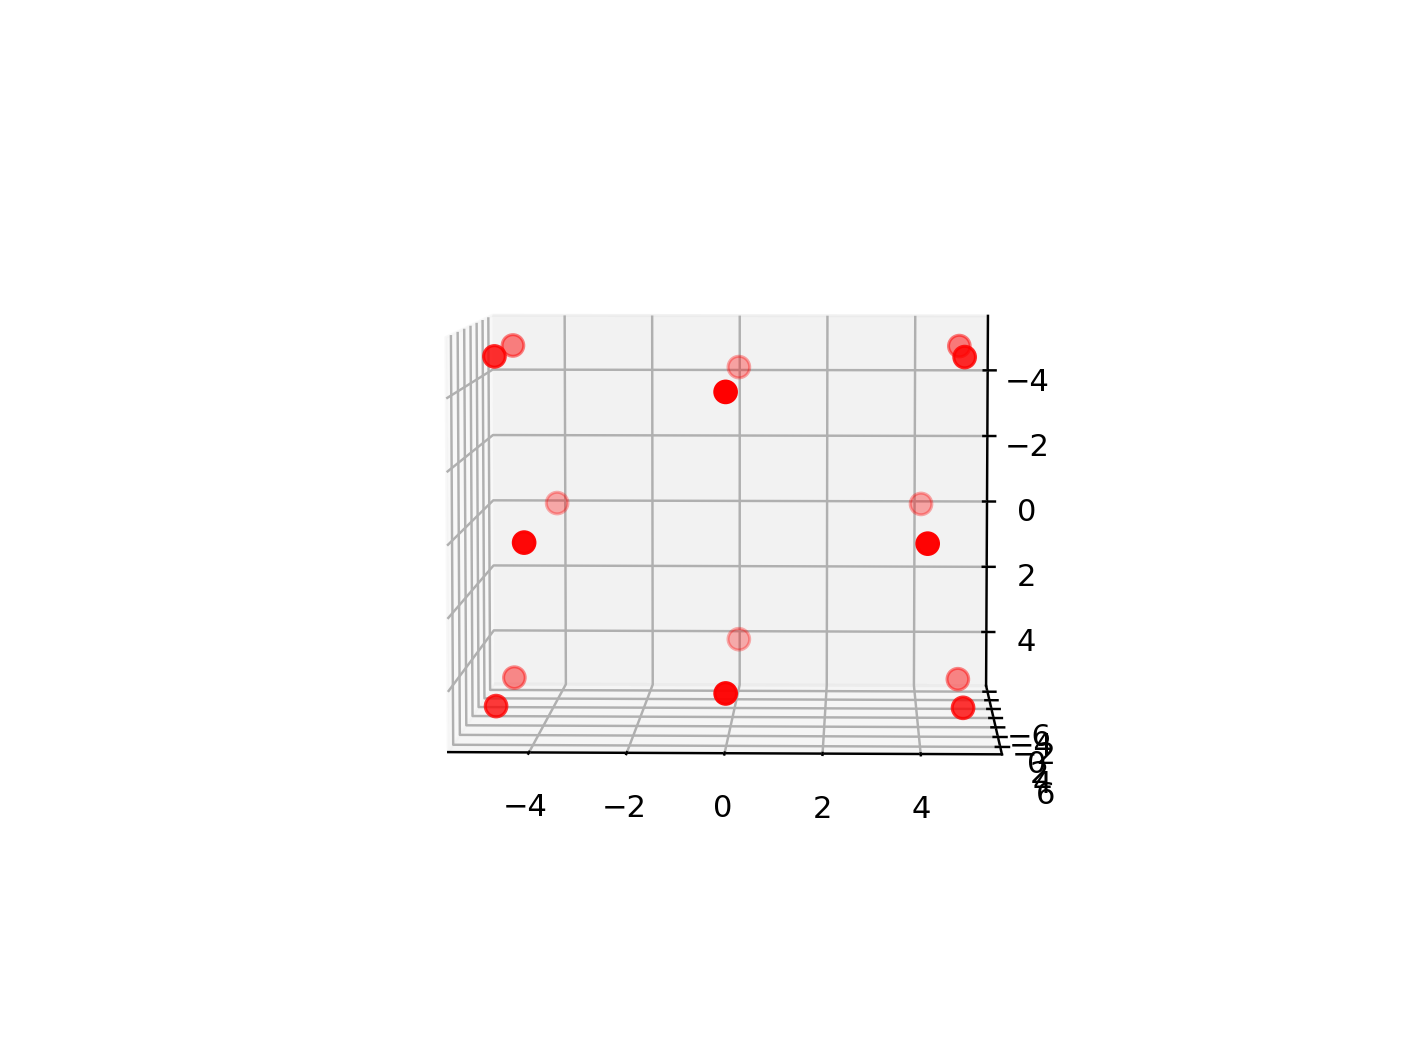

In [60]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x, y, z, c = 'r', s = 50)

In [61]:
#help function
def distance(p1,p2):
    '''point =np.array([x,y,z])'''
    return np.sqrt(np.sum((p1-p2)**2, axis=0))

In [62]:
#help function
def exclude_detector(point,sphere_center=(0,0,0),r=inner_radius):
    return distance(point,sphere_center)<r

In [69]:
# x = the tip of the cone
# dir = the normalized axis vector, pointing from the tip to the base
# h = height
# r = base radius

# p = point to test
# So you project p onto dir to find the point's distance along the axis:

# cone_dist = dot(p - x, dir)
# At this point, you can reject values outside 0 <= cone_dist <= h.

# Then you calculate the cone radius at that point along the axis:

# cone_radius = (cone_dist / h) * r
# And finally calculate the point's orthogonal distance from the axis to compare against the cone radius:

# orth_distance = length((p - x) - cone_dist * dir)

# is_point_inside_cone = (orth_distance < cone_radius)

def inside_pmt_fov_cone(point_to_test,tip_coord ,opening_angle=fov):
    '''tip coord are vec1-8'''
    #print(point_to_test,tip_coord)      
    tip_coord=np.squeeze(np.asarray(tip_coord))
    correct_y_direction=tip_coord[1]*point_to_test[1] 
    cone_direction_vec=tip_coord/LA.norm(tip_coord)
    #print(cone_direction_vec,print(type(cone_direction_vec)))
    projection_on_cone_axis=np.dot(point_to_test-tip_coord, cone_direction_vec)
    #print(projection_on_cone_axis)
    orth_distance = LA.norm((point_to_test - tip_coord) - projection_on_cone_axis * cone_direction_vec)
    #print(orth_distance)
    true_angle = np.arcsin(orth_distance/LA.norm(point_to_test-tip_coord))
    #print(true_angle,opening_angle)
    if (true_angle<opening_angle) & (correct_y_direction>0):
        #print(True)
        return True
    else:
        #print(False)
        return False

In [72]:
test_point_outside=np.array([200,300,100])
inside_pmt_fov_cone(test_point_outside,vec1)

True

In [73]:
#cm
def generate_animal_coordinates(width=1000, length=1000, height=100):#cm
    x1,x2= -500,500
    y1,y2= -500,500
    z1,z2= -500,500
    n = 100
    rng = np.random.default_rng()
    coordinates = rng.uniform([x1, y1, z1], [x2, y2, z2], size=(n, 3))
    return coordinates

In [74]:
def if_detected(coordinates,tip_coord):
    '''return a bool mask'''
    detect_mask=[]
    for coord in coordinates:
        if exclude_detector(coord):
            detect_mask.append(False)
        else: 
            detect_mask.append(inside_pmt_fov_cone(coord,tip_coord))
    return detect_mask

<IPython.core.display.Javascript object>


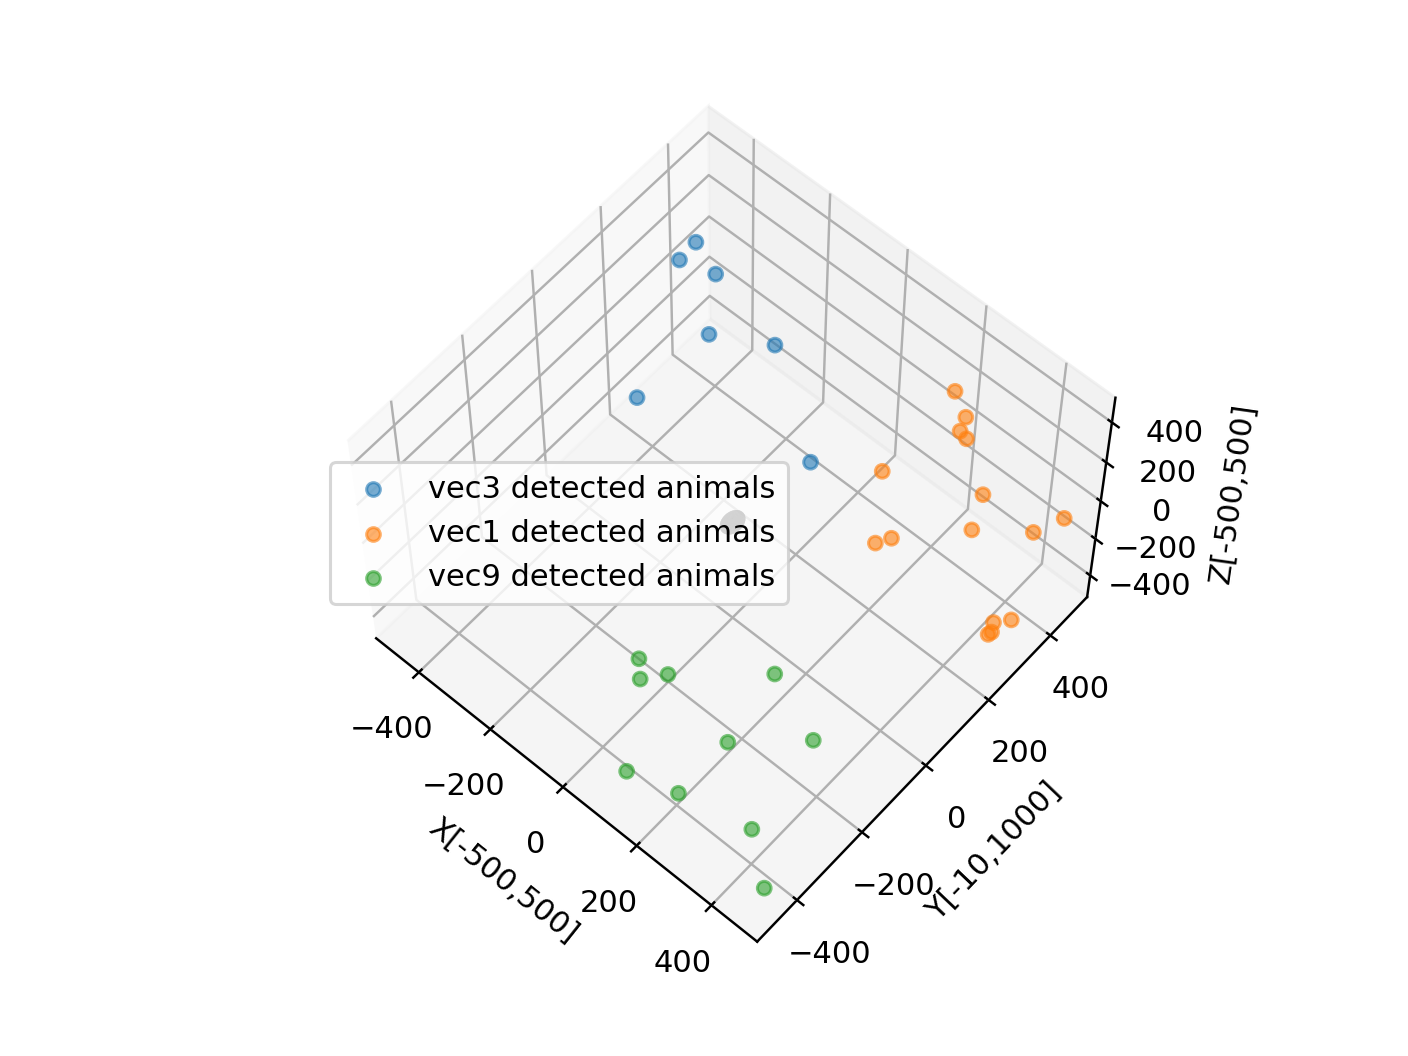

In [76]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Make data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = 21.5 * np.outer(np.cos(u), np.sin(v))
y = 30 * np.outer(np.sin(u), np.sin(v))
z = 21.5 * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x, y, z,color='black',alpha=0.8)
ax.set_xlim([-500,500])
ax.set_ylim([-500,500])
ax.set_zlim([-500,500])

animals=generate_animal_coordinates()
#ax.scatter(animals[:,0:1],animals[:,1:2],animals[:,2:3],label='all animals',alpha=0.6)


test_mask_vec3=if_detected(animals,tip_coord=vec3)
test_mask_vec1=if_detected(animals,tip_coord=vec1)
test_mask_vec9=if_detected(animals,tip_coord=vec9)
masked_animals_vec3 = animals[test_mask_vec3]
masked_animals_vec1 = animals[test_mask_vec1]
masked_animals_vec9 = animals[test_mask_vec9]
ax.scatter(masked_animals_vec3[:,0:1],masked_animals_vec3[:,1:2],masked_animals_vec3[:,2:3],label='vec3 detected animals',alpha=0.6)
ax.scatter(masked_animals_vec1[:,0:1],masked_animals_vec1[:,1:2],masked_animals_vec1[:,2:3],label='vec1 detected animals',alpha=0.6)
ax.scatter(masked_animals_vec9[:,0:1],masked_animals_vec9[:,1:2],masked_animals_vec9[:,2:3],label='vec9 detected animals',alpha=0.6)

ax.set_xlabel('X[-500,500]')
ax.set_ylabel('Y[-10,1000]')
ax.set_zlabel('Z[-500,500]')

plt.legend()